# NMT Seq2Seq (Bi-GRU + Attention) Model: English to Bengali/Hindi

This notebook implements a full sequence-to-sequence (Seq2Seq) pipeline for neural machine translation (NMT) from scratch in PyTorch.

**Key Features:**
* **Architecture:** Encoder-Decoder Model using a **Bidirectional GRU (Bi-GRU)** Encoder, a standard **GRU** Decoder, and **Bahdanau/Luong-style Attention**.
* **Training:** Uses **Teacher Forcing** to stabilize and speed up training.
* **Data:** Loads data from `train_data1.json`, predicts on `val_data1.json`, and predicts on `test_data1.json`.
* **Reusability:** The notebook is parameterized to run for one language pair at a time (e.g., English-Bengali). You can easily re-run it for English-Hindi by changing a single variable (`LANG_PAIR_KEY`).

## Step 1: Imports and Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import json
import numpy as np
import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import time
import math

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import threading, time, os, shutil

# def background_watchdog():
#     save_path = '/content/drive/MyDrive/colab_outputs/'
#     os.makedirs(save_path, exist_ok=True)

#     watched_files = ['answersB.csv', 'answersH.csv', 'answersBH.csv', 'answer.csv']
#     print(f"Watchdog started. Watching for: {watched_files}")

#     while True:
#         for f in watched_files[:]:  # iterate over a copy of the list
#             if os.path.exists(f):
#                 try:
#                     shutil.copy(f, save_path)
#                     print(f"[Watchdog] {f} copied to Drive.")
#                     watched_files.remove(f)
#                 except Exception as e:
#                     print(f"[Watchdog] Error copying {f}: {e}")
#         if not watched_files:
#             print("[Watchdog] All files saved. Stopping.")
#             break
#         time.sleep(60)  # check every minute

# # start thread in background
# threading.Thread(target=background_watchdog, daemon=True).start()


Watchdog started. Watching for: ['answersB.csv', 'answersH.csv', 'answersBH.csv', 'answer.csv']


In [ ]:
# Download the NLTK tokenizer models
# The toy model used 'punkt_tab', which is required by the environment.
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# -- Constants and Configuration --

# 1. CHOOSE YOUR LANGUAGE PAIR KEY (from the JSON file)
# Run once with "English-Bengali", then re-run with "English-Hindi"
LANG_PAIR_KEY = "English-Bengali"
# LANG_PAIR_KEY = "English-Hindi"

# 2. SET YOUR FILE PATHS (Update these to your Google Drive paths)
# Assuming data is in a folder named 'NMT_data' in your 'My Drive'
#BASE_PATH = "/content/drive/My Drive/NMT_data/"
TRAIN_FILE_PATH = "/kaggle/input/nmt-trainval-data/train_data1.json" # Using local path from toy model
VAL_FILE_PATH = "/kaggle/input/nmt-trainval-data/val_data1.json"     # You will need to upload this
TEST_FILE_PATH = "/kaggle/input/nmt-trainval-data/val_data1.json" # Using local path from toy model

# 3. DEFINE SPECIAL TOKENS
PAD_token = 0
SOS_token = 1
EOS_token = 2

# 4. SET DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 5. SET OUTPUT FILENAME (change this for the second run)
if LANG_PAIR_KEY == "English-Bengali":
    OUTPUT_CSV_NAME = "answersB.csv"
    BEST_MODEL_NAME = "best-model-bengali-bigru.pt"
else:
    OUTPUT_CSV_NAME = "answersH.csv"
    BEST_MODEL_NAME = "best-model-hindi-bigru.pt"

Using device: cuda


## Step 2: Data Loading

We'll load the train, validation, and test JSON files.

In [ ]:
# Load Train data
try:
    with open(TRAIN_FILE_PATH, 'r') as file:
        train_data = json.load(file)
    print(f"Successfully loaded {TRAIN_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {TRAIN_FILE_PATH} not found. Please upload it or check the path.")

Successfully loaded /content/train_data1.json


In [ ]:
# Load Validation data
# Note: This file is for submission, not for loss calculation as it lacks 'target' keys.
try:
    with open(VAL_FILE_PATH, 'r') as file:
        val_data = json.load(file)
    print(f"Successfully loaded {VAL_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {VAL_FILE_PATH} not found. Please upload it or check the path.")
    val_data = None # Set to None if not found so the code can proceed

Successfully loaded /content/val_data1.json


In [ ]:
# Load Test data
try:
    with open(TEST_FILE_PATH, 'r') as file:
        test_data = json.load(file)
    print(f"Successfully loaded {TEST_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {TEST_FILE_PATH} not found. Please upload it or check the path.")

Successfully loaded /content/val_data1.json


## Step 3: Data Extraction and Preprocessing

In [ ]:
def extract_data(data, lang_pair_key, split):
    """Extracts source sentences, target sentences, and IDs from the loaded JSON data."""
    source_sentences = []
    target_sentences = []
    entry_ids = []

    print(f"Extracting data for {lang_pair_key} - {split}...")

    # Check if the language pair and split exist
    if data is None:
        print(f"Error: Data for {split} is None (file not found?).")
        return [], [], []
    if lang_pair_key not in data:
        print(f"Error: Language pair '{lang_pair_key}' not in data.")
        return [], [], []
    if split not in data[lang_pair_key]:
        print(f"Error: Split '{split}' not in data for {lang_pair_key}.")
        return [], [], []

    data_entries = data[lang_pair_key][split]

    for entry_id, entry_data in data_entries.items():
        entry_ids.append(entry_id)
        source_sentences.append(entry_data["source"])

        # Test/Val sets do not have a 'target' key
        if "target" in entry_data:
            target_sentences.append(entry_data["target"])

    if not target_sentences and split == "Train":
        print(f"Warning: No target sentences found for {split} split.")
        return source_sentences, None, entry_ids

    if split != "Train":
        return source_sentences, None, entry_ids

    return source_sentences, target_sentences, entry_ids

In [ ]:
# Extract data for all splits
source_sentences_train, target_sentences_train, id_train = extract_data(train_data, LANG_PAIR_KEY, "Train")
source_sentences_val, _, id_val = extract_data(val_data, LANG_PAIR_KEY, "Validation")
source_sentences_test, _, id_test = extract_data(test_data, LANG_PAIR_KEY, "Test")

print("\n--- Data Loading Summary ---")
print(f"Train examples: {len(source_sentences_train)}")
print(f"Valid examples: {len(source_sentences_val)}")
print(f"Test examples:  {len(source_sentences_test)}")

print("\nExample Train Pair:")
if source_sentences_train:
    print(f"  EN: {source_sentences_train[0]}")
    print(f"  TGT: {target_sentences_train[0]}")

Extracting data for English-Bengali - Train...
Extracting data for English-Bengali - Validation...
Extracting data for English-Bengali - Test...
Error: Split 'Test' not in data for English-Bengali.

--- Data Loading Summary ---
Train examples: 68849
Valid examples: 9836
Test examples:  0

Example Train Pair:
  EN: Do not forget to visit the point where the Narmada flowing through the marble rocks interchanges its calmness and serenity into insouciance.
  TGT: এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী মার্বেল পাথরের পাহাড়ের মধ্য দিয়ে প্রবাহিত হচ্ছে এবং নিজের শান্তি ও সৌন্দর্যকে অনাসক্তিতে পরিণত করছে।


In [ ]:
def preprocess_sentence(sentence, lang='en'):
    """Cleans, normalizes, and tokenizes a single sentence."""

    # 1. Lowercase
    sentence = sentence.lower()

    # 2. Remove punctuation and numbers
    sentence = re.sub(r'[' + string.punctuation + ']', '', sentence)
    sentence = re.sub(r'[0-9]+', '', sentence)

    # 3. (For Target Only) Remove any stray English chars
    if lang == 'tgt':
        sentence = re.sub(r'[a-zA-Z]', '', sentence)

    # 4. Remove extra whitespace
    sentence = re.sub(r'\s+', ' ', sentence).strip()

    # 5. Tokenize
    return nltk.word_tokenize(sentence)

In [ ]:
# Preprocess all sentences
print("Preprocessing (tokenizing) sentences...")
en_train_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_train)]
tgt_train_tokens = [preprocess_sentence(s, lang='tgt') for s in tqdm(target_sentences_train)]

en_val_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_val)]
# We don't have validation targets, so this list will be empty
tgt_val_tokens = None

en_test_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_test)]

print("\nExample processed pair:")
if en_train_tokens:
    print(f"  EN: {en_train_tokens[0]}")
    print(f"  TGT: {tgt_train_tokens[0]}")

Preprocessing (tokenizing) sentences...


100%|██████████| 9836/9836 [00:00<00:00, 10403.63it/s]
0it [00:00, ?it/s]


Example processed pair:
  EN: ['do', 'not', 'forget', 'to', 'visit', 'the', 'point', 'where', 'the', 'narmada', 'flowing', 'through', 'the', 'marble', 'rocks', 'interchanges', 'its', 'calmness', 'and', 'serenity', 'into', 'insouciance']
  TGT: ['এই', 'জায়গাগুলো', 'দেখতে', 'ভুলো', 'না', 'যেখানে', 'নর্মদা', 'নদী', 'মার্বেল', 'পাথরের', 'পাহাড়ের', 'মধ্য', 'দিয়ে', 'প্রবাহিত', 'হচ্ছে', 'এবং', 'নিজের', 'শান্তি', 'ও', 'সৌন্দর্যকে', 'অনাসক্তিতে', 'পরিণত', 'করছে।']


## Step 4: Vocabulary Building

We **only** build the vocabulary from the **training set**.

In [ ]:
class Vocab:
    def __init__(self):
        self.word2index = {"<PAD>": PAD_token, "<SOS>": SOS_token, "<EOS>": EOS_token}
        self.index2word = {PAD_token: "<PAD>", SOS_token: "<SOS>", EOS_token: "<EOS>"}
        self.n_words = 3  # Count PAD, SOS, EOS

    def add_sentence(self, sentence_tokens):
        for word in sentence_tokens:
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.n_words += 1

In [ ]:
# Build vocabularies
en_vocab = Vocab()
tgt_vocab = Vocab()

print("Building English vocab from training data...")
for sent_tokens in tqdm(en_train_tokens):
    en_vocab.add_sentence(sent_tokens)

print("Building Target vocab from training data...")
for sent_tokens in tqdm(tgt_train_tokens):
    tgt_vocab.add_sentence(sent_tokens)

print("\n--- Vocab Summary ---")
print(f"English (Source) Vocab Size: {en_vocab.n_words}")
print(f"Target Vocab Size: {tgt_vocab.n_words}")

Building English vocab from training data...


100%|██████████| 68849/68849 [00:00<00:00, 303293.19it/s]


Building Target vocab from training data...


100%|██████████| 68849/68849 [00:00<00:00, 298153.55it/s]


--- Vocab Summary ---
English (Source) Vocab Size: 53923
Target Vocab Size: 104795


## Step 5: Encoding and Padding

Convert all sentences into numerical sequences, padded/truncated to `MAX_LENGTH`.

In [ ]:
MAX_LENGTH = 25

def encode_and_pad(sentence_tokens, vocab, max_length):
    """Converts tokenized sentence to a padded/truncated list of indices."""
    encoded = [vocab.word2index["<SOS>"]]
    for token in sentence_tokens:
        if token in vocab.word2index:
            encoded.append(vocab.word2index[token])

    encoded.append(vocab.word2index["<EOS>"])

    if len(encoded) > max_length:
        encoded = encoded[:max_length - 1] + [vocab.word2index["<EOS>"]]

    n_pads = max_length - len(encoded)
    encoded.extend([vocab.word2index["<PAD>"]] * n_pads)

    return encoded

In [ ]:
print("Encoding and padding all datasets...")

en_train_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_train_tokens)]
tgt_train_encoded = [encode_and_pad(s, tgt_vocab, MAX_LENGTH) for s in tqdm(tgt_train_tokens)]

en_val_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_val_tokens)]
tgt_val_encoded = None # No validation targets

en_test_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_test_tokens)]

print("\nExample encoded pair:")
if en_train_encoded:
    print(f"  EN (tokens): {en_train_tokens[0]}")
    print(f"  EN (encoded): {en_train_encoded[0]}")
    print(f"  TGT (tokens): {tgt_train_tokens[0]}")
    print(f"  TGT (encoded): {tgt_train_encoded[0]}")

Encoding and padding all datasets...


100%|██████████| 9836/9836 [00:00<00:00, 210560.78it/s]
0it [00:00, ?it/s]


Example encoded pair:
  EN (tokens): ['do', 'not', 'forget', 'to', 'visit', 'the', 'point', 'where', 'the', 'narmada', 'flowing', 'through', 'the', 'marble', 'rocks', 'interchanges', 'its', 'calmness', 'and', 'serenity', 'into', 'insouciance']
  EN (encoded): [1, 3, 4, 5, 6, 7, 8, 9, 10, 8, 11, 12, 13, 8, 14, 15, 16, 17, 18, 19, 20, 21, 22, 2, 0]
  TGT (tokens): ['এই', 'জায়গাগুলো', 'দেখতে', 'ভুলো', 'না', 'যেখানে', 'নর্মদা', 'নদী', 'মার্বেল', 'পাথরের', 'পাহাড়ের', 'মধ্য', 'দিয়ে', 'প্রবাহিত', 'হচ্ছে', 'এবং', 'নিজের', 'শান্তি', 'ও', 'সৌন্দর্যকে', 'অনাসক্তিতে', 'পরিণত', 'করছে।']
  TGT (encoded): [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2]


## Step 6: Create PyTorch DataLoaders

In [ ]:
BATCH_SIZE = 64

# Convert to Tensors
en_train_tensor = torch.LongTensor(en_train_encoded).to(device)
tgt_train_tensor = torch.LongTensor(tgt_train_encoded).to(device)
en_val_tensor = torch.LongTensor(en_val_encoded).to(device)
en_test_tensor = torch.LongTensor(en_test_encoded).to(device)

# Create TensorDatasets
train_ds = TensorDataset(en_train_tensor, tgt_train_tensor)
test_ds = TensorDataset(en_test_tensor) # For test set predictions
val_pred_ds = TensorDataset(en_val_tensor) # For validation set predictions

# Create DataLoaders
train_loader = DataLoader(train_ds, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, shuffle=False, batch_size=1) # batch_size=1 for inference
val_pred_loader = DataLoader(val_pred_ds, shuffle=False, batch_size=1) # batch_size=1 for inference

# We will not have a validation loss loader
val_loader = None

print(f"Train DataLoader: {len(train_loader)} batches of size {BATCH_SIZE}")
print(f"Test Inference Loader:  {len(test_loader)} batches of size 1")
print(f"Valid Inference Loader: {len(val_pred_loader)} batches of size 1")
print("No validation targets found. Validation loss will not be calculated.")

Train DataLoader: 1076 batches of size 64
Test Inference Loader:  0 batches of size 1
Valid Inference Loader: 9836 batches of size 1
No validation targets found. Validation loss will not be calculated.


## Step 7: Model Architecture (Bi-GRU + Attention)

This is the core of the new model.
1.  `EncoderBiGRU`: A Bidirectional GRU. It returns all output states (for attention) and a transformed hidden state (to initialize the decoder).
2.  `Attention`: A (Luong-style) attention module that calculates attention weights.
3.  `DecoderGRU`: A standard GRU that uses the `Attention` module to create a context vector, which it concatenates with the word embedding before feeding to the GRU.
4.  `Seq2Seq`: The wrapper to orchestrate the new modules.

In [ ]:
class EncoderBiGRU(nn.Module):
    def __init__(self, input_size, embed_size, enc_hidden_size, dec_hidden_size, num_layers, dropout_p):
        super(EncoderBiGRU, self).__init__()
        self.num_layers = num_layers
        self.enc_hidden_size = enc_hidden_size

        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(
            embed_size,
            enc_hidden_size,
            num_layers,
            dropout=dropout_p,
            batch_first=True,
            bidirectional=True # This is the key change
        )

        # Fully-connected layer to transform the concatenated hidden states
        # from the Bi-GRU to the decoder's expected hidden size.
        # Input: enc_hidden_size * 2 (fwd + bwd) * num_layers
        # Output: dec_hidden_size * num_layers
        self.fc_hidden = nn.Linear(enc_hidden_size * 2, dec_hidden_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, seq_len, embed_size)

        # outputs = all hidden states from all timesteps
        # hidden = final hidden state (fwd & bwd) for all layers
        outputs, hidden = self.gru(embedded)

        # outputs shape: (batch_size, seq_len, enc_hidden_size * 2)
        # hidden shape: (num_layers * 2, batch_size, enc_hidden_size)

        # 'hidden' has fwd and bwd states interleaved: [fwd_L0, bwd_L0, fwd_L1, bwd_L1 ...]
        # We need to reshape and concatenate them to match the decoder's layers.
        # Reshape to (num_layers, 2, batch_size, enc_hidden_size)
        hidden = hidden.view(self.num_layers, 2, -1, self.enc_hidden_size)

        # Concatenate fwd (dim 0) and bwd (dim 1) states
        # hidden_cat shape: (num_layers, batch_size, enc_hidden_size * 2)
        hidden_cat = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)

        # Pass through the linear layer and apply tanh activation
        # This becomes the decoder's initial hidden state
        decoder_hidden_0 = torch.tanh(self.fc_hidden(hidden_cat))
        # decoder_hidden_0 shape: (num_layers, batch_size, dec_hidden_size)

        # We return 'outputs' for the attention mechanism
        return outputs, decoder_hidden_0

In [ ]:
class Attention(nn.Module):
    def __init__(self, enc_hidden_size, dec_hidden_size):
        super(Attention, self).__init__()

        # Luong "concat" style attention
        # We need to multiply enc_hidden_size by 2 for the bidirectional outputs
        self.W1 = nn.Linear(dec_hidden_size + enc_hidden_size * 2, dec_hidden_size)
        self.V = nn.Linear(dec_hidden_size, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden shape: (num_layers, batch_size, dec_hidden_size)
        # encoder_outputs shape: (batch_size, src_len, enc_hidden_size * 2)

        src_len = encoder_outputs.shape[1]

        # We only use the top layer of the decoder's hidden state
        # top_decoder_hidden shape: (batch_size, dec_hidden_size)
        top_decoder_hidden = decoder_hidden[-1, :, :]

        # Repeat the decoder hidden state 'src_len' times
        # hidden_rep shape: (batch_size, src_len, dec_hidden_size)
        hidden_rep = top_decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)

        # Concatenate the repeated hidden state with the encoder outputs
        # energy_pre shape: (batch_size, src_len, dec_hid_size + enc_hid_size * 2)
        energy_pre = torch.cat((hidden_rep, encoder_outputs), dim=2)

        # Calculate the energy (alignment scores)
        # energy shape: (batch_size, src_len, dec_hidden_size)
        energy = torch.tanh(self.W1(energy_pre))

        # Get attention scores
        # attention_scores shape: (batch_size, src_len)
        attention_scores = self.V(energy).squeeze(2)

        # Return softmax-normalized weights
        # shape: (batch_size, src_len)
        return F.softmax(attention_scores, dim=1)


In [ ]:
class DecoderGRU(nn.Module):
    def __init__(self, output_size, embed_size, enc_hidden_size, dec_hidden_size, num_layers, dropout_p, attention):
        super(DecoderGRU, self).__init__()
        self.output_size = output_size
        self.attention = attention

        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)

        # The input to the GRU is the concatenation of the word embedding
        # and the context vector (from attention, which is size enc_hidden_size * 2)
        self.gru = nn.GRU(
            embed_size + enc_hidden_size * 2,
            dec_hidden_size,
            num_layers,
            dropout=dropout_p,
            batch_first=True
        )

        # The final output layer takes the GRU output AND the context vector
        self.fc_out = nn.Linear(dec_hidden_size + enc_hidden_size * 2, output_size)

    def forward(self, x, hidden, encoder_outputs):
        # x shape: (batch_size) - just the current token
        # hidden shape: (num_layers, batch_size, dec_hidden_size)
        # encoder_outputs shape: (batch_size, src_len, enc_hidden_size * 2)

        # Add a sequence length dimension of 1 to x
        x = x.unsqueeze(1)
        # x shape: (batch_size, 1)

        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, 1, embed_size)

        # 1. Get attention weights
        # a_weights shape: (batch_size, src_len)
        a_weights = self.attention(hidden, encoder_outputs)

        # 2. Create context vector (weighted sum of encoder outputs)
        # a_weights needs shape (batch_size, 1, src_len) for batch matrix multiply
        # context shape: (batch_size, 1, enc_hidden_size * 2)
        context = torch.bmm(a_weights.unsqueeze(1), encoder_outputs)

        # 3. Concatenate embedding and context vector
        # gru_input shape: (batch_size, 1, embed_size + enc_hidden_size * 2)
        gru_input = torch.cat((embedded, context), dim=2)

        # 4. Pass through GRU
        # gru_output shape: (batch_size, 1, dec_hidden_size)
        gru_output, hidden = self.gru(gru_input, hidden)

        # 5. Concatenate GRU output and context for final prediction
        # (Remove the 'seq_len' dim of 1)
        # pred_input shape: (batch_size, dec_hidden_size + enc_hidden_size * 2)
        pred_input = torch.cat((gru_output, context), dim=2).squeeze(1)

        # 6. Get final prediction (logits)
        # prediction shape: (batch_size, output_size)
        prediction = self.fc_out(pred_input)

        return prediction, hidden

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        # No need for assertions, encoder linear layer handles size mismatch

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src shape: (batch_size, src_len)
        # tgt shape: (batch_size, tgt_len)

        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_size

        # Tensor to store all decoder outputs
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        # 1. Pass the source sentence through the encoder
        # encoder_outputs is for attention
        # hidden is the initial decoder hidden state
        encoder_outputs, hidden = self.encoder(src)

        # 2. Decoder loop
        # First input is the <SOS> token
        x = tgt[:, 0]

        for t in range(1, tgt_len):
            # Pass the input token, previous hidden state, and all encoder outputs
            output, hidden = self.decoder(x, hidden, encoder_outputs)

            # Store this prediction
            outputs[:, t] = output

            # Decide whether to use 'teacher forcing'
            use_teacher_forcing = random.random() < teacher_forcing_ratio

            # Get the token with the highest score
            top1 = output.argmax(1)

            # Set the next input
            x = tgt[:, t] if use_teacher_forcing else top1

        return outputs

## Step 8: Training the Model

In [ ]:
# -- Hyperparameters --
INPUT_DIM = en_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words
EMBED_SIZE = 256        # Size of token embeddings
ENC_HIDDEN_SIZE = 512   # Encoder GRU hidden size
DEC_HIDDEN_SIZE = 512   # Decoder GRU hidden size (must be matched by encoder's fc_hidden)
NUM_LAYERS = 2          # Number of layers in the GRUs
DROPOUT = 0.5           # Dropout probability
LEARNING_RATE = 0.001   # Adam optimizer learning rate
NUM_EPOCHS = 3
CLIP = 1.0              # Gradient clipping value
TEACHER_FORCING_RATIO = 0.5

# -- Model Instantiation --
attn = Attention(ENC_HIDDEN_SIZE, DEC_HIDDEN_SIZE).to(device)

encoder = EncoderBiGRU(INPUT_DIM, EMBED_SIZE, ENC_HIDDEN_SIZE, DEC_HIDDEN_SIZE,
                       NUM_LAYERS, DROPOUT).to(device)

decoder = DecoderGRU(OUTPUT_DIM, EMBED_SIZE, ENC_HIDDEN_SIZE, DEC_HIDDEN_SIZE,
                     NUM_LAYERS, DROPOUT, attn).to(device)

model = Seq2Seq(encoder, decoder, device).to(device)

# -- Optimizer and Loss --
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

print("--- Model Summary ---")
print(f"Source (EN) Vocab: {INPUT_DIM}")
print(f"Target (TGT) Vocab: {OUTPUT_DIM}")
print(f"Embedding Size: {EMBED_SIZE}")
print(f"Encoder Hidden Size: {ENC_HIDDEN_SIZE} (Bidirectional)")
print(f"Decoder Hidden Size: {DEC_HIDDEN_SIZE}")
print(f"Num Layers: {NUM_LAYERS}")
print(model)

--- Model Summary ---
Source (EN) Vocab: 53923
Target (TGT) Vocab: 104795
Embedding Size: 256
Encoder Hidden Size: 512 (Bidirectional)
Decoder Hidden Size: 512
Num Layers: 2
Seq2Seq(
  (encoder): EncoderBiGRU(
    (embedding): Embedding(53923, 256, padding_idx=0)
    (dropout): Dropout(p=0.5, inplace=False)
    (gru): GRU(256, 512, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
    (fc_hidden): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): DecoderGRU(
    (attention): Attention(
      (W1): Linear(in_features=1536, out_features=512, bias=True)
      (V): Linear(in_features=512, out_features=1, bias=True)
    )
    (embedding): Embedding(104795, 256, padding_idx=0)
    (dropout): Dropout(p=0.5, inplace=False)
    (gru): GRU(1280, 512, num_layers=2, batch_first=True, dropout=0.5)
    (fc_out): Linear(in_features=1536, out_features=104795, bias=True)
  )
)


In [ ]:
def train_fn(model, loader, optimizer, criterion, clip, ratio):
    """Performs one epoch of training."""
    model.train()
    epoch_loss = 0

    for batch in tqdm(loader, desc="Training"):
        src, tgt = batch
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(src, tgt, teacher_forcing_ratio=ratio)
        # output shape: (batch_size, tgt_len, output_dim)

        # Reshape for loss function
        output_dim = output.shape[-1]
        output_for_loss = output[:, 1:].reshape(-1, output_dim)
        tgt_for_loss = tgt[:, 1:].reshape(-1)

        loss = criterion(output_for_loss, tgt_for_loss)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
def evaluate_fn(model, loader, criterion):
    """Performs one epoch of evaluation on the validation set."""
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating"):
            src, tgt = batch
            src, tgt = src.to(device), tgt.to(device)

            # Forward pass (no teacher forcing for validation)
            output = model(src, tgt, teacher_forcing_ratio=0.0)

            # Reshape for loss
            output_dim = output.shape[-1]
            output_for_loss = output[:, 1:].reshape(-1, output_dim)
            tgt_for_loss = tgt[:, 1:].reshape(-1)

            loss = criterion(output_for_loss, tgt_for_loss)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
def epoch_time(start_time, end_time):
    """Helper function to format epoch time."""
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [41]:
print("Starting Training...")

best_loss = float('inf')
train_losses = []
valid_losses = []

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # Run training
    train_loss = train_fn(model, train_loader, optimizer, criterion, CLIP, TEACHER_FORCING_RATIO)
    train_losses.append(train_loss)

    current_loss = train_loss # Default loss to track

    # Run validation (if we have a val_loader)
    if val_loader:
        valid_loss = evaluate_fn(model, val_loader, criterion)
        valid_losses.append(valid_loss)
        current_loss = valid_loss # Track validation loss if available
    else:
        valid_loss = 0.0 # No validation loss to show

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # Save the best model
    if current_loss < best_loss:
        best_loss = current_loss
        torch.save(model.state_dict(), BEST_MODEL_NAME)

    print(f'\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    if val_loader:
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')
    else:
        print(f'\t Val. Loss: N/A (No targets)')

print("Training finished.")
# If we didn't save a model based on validation, save the final epoch's model
if not val_loader:
    torch.save(model.state_dict(), BEST_MODEL_NAME)
    print(f"Saved final model as {BEST_MODEL_NAME}")

Starting Training...


Training: 100%|██████████| 1076/1076 [27:25<00:00,  1.53s/it]



Epoch: 01 | Time: 27m 25s
	Train Loss: 7.856 | Train PPL: 2580.456
	 Val. Loss: N/A (No targets)


Training: 100%|██████████| 1076/1076 [27:29<00:00,  1.53s/it]



Epoch: 02 | Time: 27m 29s
	Train Loss: 6.600 | Train PPL: 734.957
	 Val. Loss: N/A (No targets)


Training: 100%|██████████| 1076/1076 [27:32<00:00,  1.54s/it]



Epoch: 03 | Time: 27m 32s
	Train Loss: 5.595 | Train PPL: 269.183
	 Val. Loss: N/A (No targets)
Training finished.
Saved final model as best-model-bengali-bigru.pt


## Step 9: Plot Loss

Plot the training loss to see how the model learned.

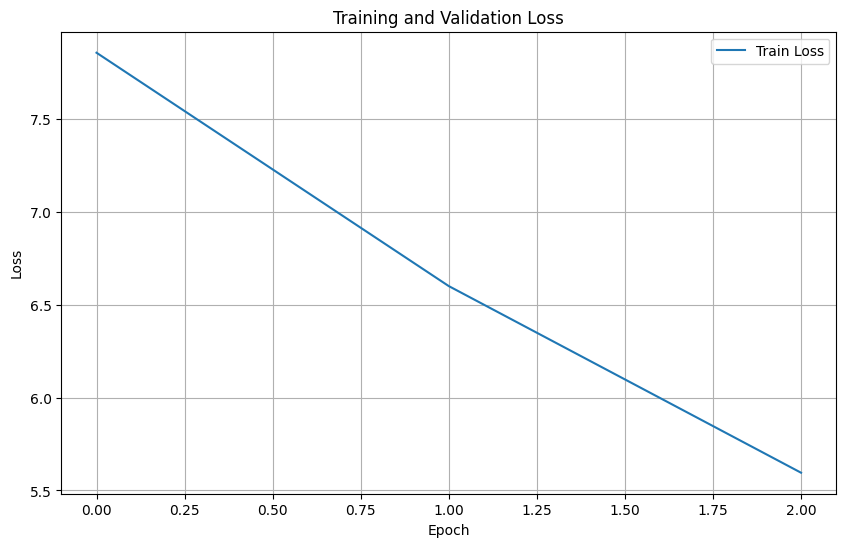

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
if valid_losses: # Only plot if list is not empty
    plt.plot(valid_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Step 10: Inference (Generate Translations)

This is the updated `translate_sentence` function for our new Bi-GRU + Attention model. It must correctly pass the `encoder_outputs` to the decoder at each step.

In [43]:
def translate_sentence(sentence_tokens, en_vocab, tgt_vocab, model, device, max_length=MAX_LENGTH):
    """Translates a single tokenized source sentence with the attention model."""

    # 1. Set model to evaluation mode
    model.eval()

    # 2. Encode and pad the source sentence
    encoded_sentence = encode_and_pad(sentence_tokens, en_vocab, max_length)

    # 3. Convert to tensor and add batch dimension (batch_size=1)
    src_tensor = torch.LongTensor(encoded_sentence).unsqueeze(0).to(device)

    # 4. Run the encoder
    with torch.no_grad():
        # encoder_outputs is for attention, hidden is the initial decoder state
        encoder_outputs, hidden = model.encoder(src_tensor)

    # 5. Start decoder loop with <SOS> token
    input_token = torch.LongTensor([SOS_token]).to(device)

    translated_indices = []

    for _ in range(max_length):
        # 6. Decoder forward pass (requires current token, prev hidden, and ALL encoder outputs)
        with torch.no_grad():
            output, hidden = model.decoder(input_token, hidden, encoder_outputs)

        # 7. Get the most likely token (greedy decoding)
        top1 = output.argmax(1)
        predicted_index = top1.item()

        # 8. If <EOS>, stop translating
        if predicted_index == EOS_token:
            break

        translated_indices.append(predicted_index)

        # 9. Set the next decoder input to the predicted token
        input_token = top1

    # 10. Convert indices back to words
    translated_words = [tgt_vocab.index2word[idx] for idx in translated_indices]

    return " ".join(translated_words)

In [44]:
# Load the best model weights
print(f"Loading best model from {BEST_MODEL_NAME}")
try:
    model.load_state_dict(torch.load(BEST_MODEL_NAME))
except FileNotFoundError:
    print("WARNING: No saved model found. Using the model from the last epoch.")

# --- Generate translations for the VALIDATION set ---
val_translations = []
print(f"Generating {len(en_val_tokens)} translations for the VALIDATION set...")
for tokens in tqdm(en_val_tokens):
    translation = translate_sentence(tokens, en_vocab, tgt_vocab, model, device, MAX_LENGTH)
    val_translations.append(translation)

# --- Generate translations for the TEST set ---
test_translations = []
print(f"Generating {len(en_test_tokens)} translations for the TEST set...")
for tokens in tqdm(en_test_tokens):
    translation = translate_sentence(tokens, en_vocab, tgt_vocab, model, device, MAX_LENGTH)
    test_translations.append(translation)

print("Translation generation complete.")

Loading best model from best-model-bengali-bigru.pt
Generating 9836 translations for the VALIDATION set...


100%|██████████| 9836/9836 [08:16<00:00, 19.80it/s]


Generating 0 translations for the TEST set...


0it [00:00, ?it/s]

Translation generation complete.


## Step 11: Create Submission Files

In [ ]:
# --- Save TEST SET Predictions (for final submission) ---
df_submission_test = pd.DataFrame()
df_submission_test["ID"] = id_test
df_submission_test["Translation"] = test_translations

# Save to CSV (e.g., answersB.csv or answersH.csv)
df_submission_test.to_csv(OUTPUT_CSV_NAME, index=False)
print(f"TEST set submission file saved as {OUTPUT_CSV_NAME}")
print(df_submission_test.head())

# --- Save VALIDATION SET Predictions (for weekly submissions) ---
#val_output_name = f"val_{OUTPUT_CSV_NAME}" # e.g., val_answersB.csv
df_submission_val = pd.DataFrame()
df_submission_val["ID"] = id_val
df_submission_val["Translation"] = val_translations

df_submission_val.to_csv(OUTPUT_CSV_NAME, index=False)
print(f"\nVALIDATION set submission file saved as {OUTPUT_CSV_NAME}")
print(df_submission_val.head())

---
## 🚀 Next Steps: Run for Hindi

You have now successfully trained a model and generated `answersB.csv` (for Bengali).

**To get the Hindi translations, you must re-run this entire notebook:**
1.  **Restart the Runtime:** Go to `Runtime` > `Restart runtime` to clear all variables.
2.  **Change `LANG_PAIR_KEY`:** In **Step 1 (Cell 4)**, change the `LANG_PAIR_KEY` variable to:
    ```python
    LANG_PAIR_KEY = "English-Hindi"
    ```
3.  **Run All Cells:** Go to `Runtime` > `Run all`.

This will automatically set the `OUTPUT_CSV_NAME` to `answersH.csv` and `BEST_MODEL_NAME` to `best-model-hindi-bigru.pt`, training a new model on the Hindi data and saving the correct output file.

---

## Final Step: Combine and Format for Submission

Once you have **both** `answersB.csv` and `answersH.csv`, run the following cells.

In [ ]:
# # Make sure both files exist before running this!
# try:
#     df_bengali = pd.read_csv("/content/answersB.csv") # Bengali
#     df_hindi = pd.read_csv("/content/answersH.csv")  # Hindi

#     print(f"Loaded {len(df_bengali)} Bengali translations.")
#     print(f"Loaded {len(df_hindi)} Hindi translations.")

#     # Concat
#     df_combined = pd.concat([df_bengali, df_hindi])
#     print(f"Combined total translations: {len(df_combined)}")

#     # Save combined CSV
#     df_combined.to_csv('answersBH.csv', index=False)

#     # Display head
#     df_combined.head()

# except FileNotFoundError as e:
#     print(f"ERROR: Could not find file. {e}")
#     print("Please make sure you have run the notebook for BOTH language pairs and generated 'answersB.csv' and 'answersH.csv'.")

In [ ]:
# # Format into the final tab-separated answer.csv
# try:
#     filtered_data = pd.read_csv("/content/answersBH.csv")

#     # Fill any NaN translations with an empty string to avoid errors
#     filtered_data['Translation'] = filtered_data['Translation'].fillna('')

#     answer_file = "/content/answer.csv"
#     with open(answer_file, "w") as f:
#       f.writelines("ID\tTranslation\n")
#       for i in range(filtered_data.shape[0]):
#         # Ensure translation is a string and handle quotes inside it
#         translation_text = str(filtered_data["Translation"][i]).replace('"', '""')
#         f.writelines(f'{filtered_data["ID"][i]}\t"{translation_text}"\n')

#     print(f"Successfully created final 'answer.csv'")
# except NameError:
#     print("ERROR: 'filtered_data' not defined. Did the cell above run correctly?")
# except FileNotFoundError:
#      print("ERROR: 'answersBH.csv' not found. Did the cell above run correctly?")

### Make a zip file of answer.csv and save it as submission.zip and submit it

In [48]:
# # This will create a submission.zip file in your Colab environment
# !zip submission.zip /content/answer.csv

# HINDI PART

In [49]:
# -- Constants and Configuration --

# 1. CHOOSE YOUR LANGUAGE PAIR KEY (from the JSON file)
# Run once with "English-Bengali", then re-run with "English-Hindi"
LANG_PAIR_KEY = "English-Bengali"
# LANG_PAIR_KEY = "English-Hindi"

# 2. SET YOUR FILE PATHS (Update these to your Google Drive paths)
# Assuming data is in a folder named 'NMT_data' in your 'My Drive'
#BASE_PATH = "/content/drive/My Drive/NMT_data/"
TRAIN_FILE_PATH = "/kaggle/input/nmt-trainval-data/train_data1.json" # Using local path from toy model
VAL_FILE_PATH = "/kaggle/input/nmt-trainval-data/val_data1.json"     # You will need to upload this
TEST_FILE_PATH = "/kaggle/input/nmt-trainval-data/val_data1.json" # Using local path from toy model

# 3. DEFINE SPECIAL TOKENS
PAD_token = 0
SOS_token = 1
EOS_token = 2

# 4. SET DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 5. SET OUTPUT FILENAME (change this for the second run)
if LANG_PAIR_KEY == "English-Bengali":
    OUTPUT_CSV_NAME = "answersB.csv"
    BEST_MODEL_NAME = "best-model-bengali-bigru.pt"
else:
    OUTPUT_CSV_NAME = "answersH.csv"
    BEST_MODEL_NAME = "best-model-hindi-bigru.pt"

Using device: cuda


## Step 2: Data Loading

We'll load the train, validation, and test JSON files.

In [50]:
# Load Train data
try:
    with open(TRAIN_FILE_PATH, 'r') as file:
        train_data = json.load(file)
    print(f"Successfully loaded {TRAIN_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {TRAIN_FILE_PATH} not found. Please upload it or check the path.")

Successfully loaded /content/train_data1.json


In [51]:
# Load Validation data
# Note: This file is for submission, not for loss calculation as it lacks 'target' keys.
try:
    with open(VAL_FILE_PATH, 'r') as file:
        val_data = json.load(file)
    print(f"Successfully loaded {VAL_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {VAL_FILE_PATH} not found. Please upload it or check the path.")
    val_data = None # Set to None if not found so the code can proceed

Successfully loaded /content/val_data1.json


In [52]:
# Load Test data
try:
    with open(TEST_FILE_PATH, 'r') as file:
        test_data = json.load(file)
    print(f"Successfully loaded {TEST_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {TEST_FILE_PATH} not found. Please upload it or check the path.")

Successfully loaded /content/val_data1.json


## Step 3: Data Extraction and Preprocessing

In [53]:
def extract_data(data, lang_pair_key, split):
    """Extracts source sentences, target sentences, and IDs from the loaded JSON data."""
    source_sentences = []
    target_sentences = []
    entry_ids = []

    print(f"Extracting data for {lang_pair_key} - {split}...")

    # Check if the language pair and split exist
    if data is None:
        print(f"Error: Data for {split} is None (file not found?).")
        return [], [], []
    if lang_pair_key not in data:
        print(f"Error: Language pair '{lang_pair_key}' not in data.")
        return [], [], []
    if split not in data[lang_pair_key]:
        print(f"Error: Split '{split}' not in data for {lang_pair_key}.")
        return [], [], []

    data_entries = data[lang_pair_key][split]

    for entry_id, entry_data in data_entries.items():
        entry_ids.append(entry_id)
        source_sentences.append(entry_data["source"])

        # Test/Val sets do not have a 'target' key
        if "target" in entry_data:
            target_sentences.append(entry_data["target"])

    if not target_sentences and split == "Train":
        print(f"Warning: No target sentences found for {split} split.")
        return source_sentences, None, entry_ids

    if split != "Train":
        return source_sentences, None, entry_ids

    return source_sentences, target_sentences, entry_ids

In [54]:
# Extract data for all splits
source_sentences_train, target_sentences_train, id_train = extract_data(train_data, LANG_PAIR_KEY, "Train")
source_sentences_val, _, id_val = extract_data(val_data, LANG_PAIR_KEY, "Validation")
source_sentences_test, _, id_test = extract_data(test_data, LANG_PAIR_KEY, "Test")

print("\n--- Data Loading Summary ---")
print(f"Train examples: {len(source_sentences_train)}")
print(f"Valid examples: {len(source_sentences_val)}")
print(f"Test examples:  {len(source_sentences_test)}")

print("\nExample Train Pair:")
if source_sentences_train:
    print(f"  EN: {source_sentences_train[0]}")
    print(f"  TGT: {target_sentences_train[0]}")

Extracting data for English-Hindi - Train...
Extracting data for English-Hindi - Validation...
Extracting data for English-Hindi - Test...
Error: Split 'Test' not in data for English-Hindi.

--- Data Loading Summary ---
Train examples: 80797
Valid examples: 11543
Test examples:  0

Example Train Pair:
  EN: cancel everything on my calendar
  TGT: मेरे कैलेंडर पर सब कुछ रद्द करें


In [55]:
def preprocess_sentence(sentence, lang='en'):
    """Cleans, normalizes, and tokenizes a single sentence."""

    # 1. Lowercase
    sentence = sentence.lower()

    # 2. Remove punctuation and numbers
    sentence = re.sub(r'[' + string.punctuation + ']', '', sentence)
    sentence = re.sub(r'[0-9]+', '', sentence)

    # 3. (For Target Only) Remove any stray English chars
    if lang == 'tgt':
        sentence = re.sub(r'[a-zA-Z]', '', sentence)

    # 4. Remove extra whitespace
    sentence = re.sub(r'\s+', ' ', sentence).strip()

    # 5. Tokenize
    return nltk.word_tokenize(sentence)

In [56]:
# Preprocess all sentences
print("Preprocessing (tokenizing) sentences...")
en_train_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_train)]
tgt_train_tokens = [preprocess_sentence(s, lang='tgt') for s in tqdm(target_sentences_train)]

en_val_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_val)]
# We don't have validation targets, so this list will be empty
tgt_val_tokens = None

en_test_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_test)]

print("\nExample processed pair:")
if en_train_tokens:
    print(f"  EN: {en_train_tokens[0]}")
    print(f"  TGT: {tgt_train_tokens[0]}")

Preprocessing (tokenizing) sentences...


 84%|████████▍ | 67724/80797 [00:08<00:01, 9822.05it/s]

[Watchdog] answersB.csv copied to Drive.


 33%|███▎      | 3859/11543 [00:00<00:00, 12470.38it/s]

[Watchdog] answersB.csv copied to Drive.


100%|██████████| 11543/11543 [00:00<00:00, 12793.74it/s]
0it [00:00, ?it/s]


Example processed pair:
  EN: ['cancel', 'everything', 'on', 'my', 'calendar']
  TGT: ['मेरे', 'कैलेंडर', 'पर', 'सब', 'कुछ', 'रद्द', 'करें']


## Step 4: Vocabulary Building

We **only** build the vocabulary from the **training set**.

In [ ]:
class Vocab:
    def __init__(self):
        self.word2index = {"<PAD>": PAD_token, "<SOS>": SOS_token, "<EOS>": EOS_token}
        self.index2word = {PAD_token: "<PAD>", SOS_token: "<SOS>", EOS_token: "<EOS>"}
        self.n_words = 3  # Count PAD, SOS, EOS

    def add_sentence(self, sentence_tokens):
        for word in sentence_tokens:
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.n_words += 1

In [ ]:
# Build vocabularies
en_vocab = Vocab()
tgt_vocab = Vocab()

print("Building English vocab from training data...")
for sent_tokens in tqdm(en_train_tokens):
    en_vocab.add_sentence(sent_tokens)

print("Building Target vocab from training data...")
for sent_tokens in tqdm(tgt_train_tokens):
    tgt_vocab.add_sentence(sent_tokens)

print("\n--- Vocab Summary ---")
print(f"English (Source) Vocab Size: {en_vocab.n_words}")
print(f"Target Vocab Size: {tgt_vocab.n_words}")

## Step 5: Encoding and Padding

Convert all sentences into numerical sequences, padded/truncated to `MAX_LENGTH`.

In [ ]:
MAX_LENGTH = 25

def encode_and_pad(sentence_tokens, vocab, max_length):
    """Converts tokenized sentence to a padded/truncated list of indices."""
    encoded = [vocab.word2index["<SOS>"]]
    for token in sentence_tokens:
        if token in vocab.word2index:
            encoded.append(vocab.word2index[token])

    encoded.append(vocab.word2index["<EOS>"])

    if len(encoded) > max_length:
        encoded = encoded[:max_length - 1] + [vocab.word2index["<EOS>"]]

    n_pads = max_length - len(encoded)
    encoded.extend([vocab.word2index["<PAD>"]] * n_pads)

    return encoded

In [60]:
print("Encoding and padding all datasets...")

en_train_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_train_tokens)]
tgt_train_encoded = [encode_and_pad(s, tgt_vocab, MAX_LENGTH) for s in tqdm(tgt_train_tokens)]

en_val_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_val_tokens)]
tgt_val_encoded = None # No validation targets

en_test_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_test_tokens)]

print("\nExample encoded pair:")
if en_train_encoded:
    print(f"  EN (tokens): {en_train_tokens[0]}")
    print(f"  EN (encoded): {en_train_encoded[0]}")
    print(f"  TGT (tokens): {tgt_train_tokens[0]}")
    print(f"  TGT (encoded): {tgt_train_encoded[0]}")

Encoding and padding all datasets...


100%|██████████| 80797/80797 [00:00<00:00, 111169.74it/s]


[Watchdog] answersB.csv copied to Drive.


100%|██████████| 11543/11543 [00:00<00:00, 200651.72it/s]
0it [00:00, ?it/s]


Example encoded pair:
  EN (tokens): ['cancel', 'everything', 'on', 'my', 'calendar']
  EN (encoded): [1, 3, 4, 5, 6, 7, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  TGT (tokens): ['मेरे', 'कैलेंडर', 'पर', 'सब', 'कुछ', 'रद्द', 'करें']
  TGT (encoded): [1, 3, 4, 5, 6, 7, 8, 9, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Step 6: Create PyTorch DataLoaders

In [ ]:
BATCH_SIZE = 64

# Convert to Tensors
en_train_tensor = torch.LongTensor(en_train_encoded).to(device)
tgt_train_tensor = torch.LongTensor(tgt_train_encoded).to(device)
en_val_tensor = torch.LongTensor(en_val_encoded).to(device)
en_test_tensor = torch.LongTensor(en_test_encoded).to(device)

# Create TensorDatasets
train_ds = TensorDataset(en_train_tensor, tgt_train_tensor)
test_ds = TensorDataset(en_test_tensor) # For test set predictions
val_pred_ds = TensorDataset(en_val_tensor) # For validation set predictions

# Create DataLoaders
train_loader = DataLoader(train_ds, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, shuffle=False, batch_size=1) # batch_size=1 for inference
val_pred_loader = DataLoader(val_pred_ds, shuffle=False, batch_size=1) # batch_size=1 for inference

# We will not have a validation loss loader
val_loader = None

print(f"Train DataLoader: {len(train_loader)} batches of size {BATCH_SIZE}")
print(f"Test Inference Loader:  {len(test_loader)} batches of size 1")
print(f"Valid Inference Loader: {len(val_pred_loader)} batches of size 1")
print("No validation targets found. Validation loss will not be calculated.")

## Step 7: Model Architecture (Bi-GRU + Attention)

This is the core of the new model.
1.  `EncoderBiGRU`: A Bidirectional GRU. It returns all output states (for attention) and a transformed hidden state (to initialize the decoder).
2.  `Attention`: A (Luong-style) attention module that calculates attention weights.
3.  `DecoderGRU`: A standard GRU that uses the `Attention` module to create a context vector, which it concatenates with the word embedding before feeding to the GRU.
4.  `Seq2Seq`: The wrapper to orchestrate the new modules.

In [62]:
class EncoderBiGRU(nn.Module):
    def __init__(self, input_size, embed_size, enc_hidden_size, dec_hidden_size, num_layers, dropout_p):
        super(EncoderBiGRU, self).__init__()
        self.num_layers = num_layers
        self.enc_hidden_size = enc_hidden_size

        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(
            embed_size,
            enc_hidden_size,
            num_layers,
            dropout=dropout_p,
            batch_first=True,
            bidirectional=True # This is the key change
        )

        # Fully-connected layer to transform the concatenated hidden states
        # from the Bi-GRU to the decoder's expected hidden size.
        # Input: enc_hidden_size * 2 (fwd + bwd) * num_layers
        # Output: dec_hidden_size * num_layers
        self.fc_hidden = nn.Linear(enc_hidden_size * 2, dec_hidden_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, seq_len, embed_size)

        # outputs = all hidden states from all timesteps
        # hidden = final hidden state (fwd & bwd) for all layers
        outputs, hidden = self.gru(embedded)

        # outputs shape: (batch_size, seq_len, enc_hidden_size * 2)
        # hidden shape: (num_layers * 2, batch_size, enc_hidden_size)

        # 'hidden' has fwd and bwd states interleaved: [fwd_L0, bwd_L0, fwd_L1, bwd_L1 ...]
        # We need to reshape and concatenate them to match the decoder's layers.
        # Reshape to (num_layers, 2, batch_size, enc_hidden_size)
        hidden = hidden.view(self.num_layers, 2, -1, self.enc_hidden_size)

        # Concatenate fwd (dim 0) and bwd (dim 1) states
        # hidden_cat shape: (num_layers, batch_size, enc_hidden_size * 2)
        hidden_cat = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)

        # Pass through the linear layer and apply tanh activation
        # This becomes the decoder's initial hidden state
        decoder_hidden_0 = torch.tanh(self.fc_hidden(hidden_cat))
        # decoder_hidden_0 shape: (num_layers, batch_size, dec_hidden_size)

        # We return 'outputs' for the attention mechanism
        return outputs, decoder_hidden_0

In [63]:
class Attention(nn.Module):
    def __init__(self, enc_hidden_size, dec_hidden_size):
        super(Attention, self).__init__()

        # Luong "concat" style attention
        # We need to multiply enc_hidden_size by 2 for the bidirectional outputs
        self.W1 = nn.Linear(dec_hidden_size + enc_hidden_size * 2, dec_hidden_size)
        self.V = nn.Linear(dec_hidden_size, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden shape: (num_layers, batch_size, dec_hidden_size)
        # encoder_outputs shape: (batch_size, src_len, enc_hidden_size * 2)

        src_len = encoder_outputs.shape[1]

        # We only use the top layer of the decoder's hidden state
        # top_decoder_hidden shape: (batch_size, dec_hidden_size)
        top_decoder_hidden = decoder_hidden[-1, :, :]

        # Repeat the decoder hidden state 'src_len' times
        # hidden_rep shape: (batch_size, src_len, dec_hidden_size)
        hidden_rep = top_decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)

        # Concatenate the repeated hidden state with the encoder outputs
        # energy_pre shape: (batch_size, src_len, dec_hid_size + enc_hid_size * 2)
        energy_pre = torch.cat((hidden_rep, encoder_outputs), dim=2)

        # Calculate the energy (alignment scores)
        # energy shape: (batch_size, src_len, dec_hidden_size)
        energy = torch.tanh(self.W1(energy_pre))

        # Get attention scores
        # attention_scores shape: (batch_size, src_len)
        attention_scores = self.V(energy).squeeze(2)

        # Return softmax-normalized weights
        # shape: (batch_size, src_len)
        return F.softmax(attention_scores, dim=1)


In [64]:
class DecoderGRU(nn.Module):
    def __init__(self, output_size, embed_size, enc_hidden_size, dec_hidden_size, num_layers, dropout_p, attention):
        super(DecoderGRU, self).__init__()
        self.output_size = output_size
        self.attention = attention

        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)

        # The input to the GRU is the concatenation of the word embedding
        # and the context vector (from attention, which is size enc_hidden_size * 2)
        self.gru = nn.GRU(
            embed_size + enc_hidden_size * 2,
            dec_hidden_size,
            num_layers,
            dropout=dropout_p,
            batch_first=True
        )

        # The final output layer takes the GRU output AND the context vector
        self.fc_out = nn.Linear(dec_hidden_size + enc_hidden_size * 2, output_size)

    def forward(self, x, hidden, encoder_outputs):
        # x shape: (batch_size) - just the current token
        # hidden shape: (num_layers, batch_size, dec_hidden_size)
        # encoder_outputs shape: (batch_size, src_len, enc_hidden_size * 2)

        # Add a sequence length dimension of 1 to x
        x = x.unsqueeze(1)
        # x shape: (batch_size, 1)

        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, 1, embed_size)

        # 1. Get attention weights
        # a_weights shape: (batch_size, src_len)
        a_weights = self.attention(hidden, encoder_outputs)

        # 2. Create context vector (weighted sum of encoder outputs)
        # a_weights needs shape (batch_size, 1, src_len) for batch matrix multiply
        # context shape: (batch_size, 1, enc_hidden_size * 2)
        context = torch.bmm(a_weights.unsqueeze(1), encoder_outputs)

        # 3. Concatenate embedding and context vector
        # gru_input shape: (batch_size, 1, embed_size + enc_hidden_size * 2)
        gru_input = torch.cat((embedded, context), dim=2)

        # 4. Pass through GRU
        # gru_output shape: (batch_size, 1, dec_hidden_size)
        gru_output, hidden = self.gru(gru_input, hidden)

        # 5. Concatenate GRU output and context for final prediction
        # (Remove the 'seq_len' dim of 1)
        # pred_input shape: (batch_size, dec_hidden_size + enc_hidden_size * 2)
        pred_input = torch.cat((gru_output, context), dim=2).squeeze(1)

        # 6. Get final prediction (logits)
        # prediction shape: (batch_size, output_size)
        prediction = self.fc_out(pred_input)

        return prediction, hidden

In [65]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        # No need for assertions, encoder linear layer handles size mismatch

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src shape: (batch_size, src_len)
        # tgt shape: (batch_size, tgt_len)

        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_size

        # Tensor to store all decoder outputs
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        # 1. Pass the source sentence through the encoder
        # encoder_outputs is for attention
        # hidden is the initial decoder hidden state
        encoder_outputs, hidden = self.encoder(src)

        # 2. Decoder loop
        # First input is the <SOS> token
        x = tgt[:, 0]

        for t in range(1, tgt_len):
            # Pass the input token, previous hidden state, and all encoder outputs
            output, hidden = self.decoder(x, hidden, encoder_outputs)

            # Store this prediction
            outputs[:, t] = output

            # Decide whether to use 'teacher forcing'
            use_teacher_forcing = random.random() < teacher_forcing_ratio

            # Get the token with the highest score
            top1 = output.argmax(1)

            # Set the next input
            x = tgt[:, t] if use_teacher_forcing else top1

        return outputs

## Step 8: Training the Model

In [66]:
# -- Hyperparameters --
INPUT_DIM = en_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words
EMBED_SIZE = 256        # Size of token embeddings
ENC_HIDDEN_SIZE = 512   # Encoder GRU hidden size
DEC_HIDDEN_SIZE = 512   # Decoder GRU hidden size (must be matched by encoder's fc_hidden)
NUM_LAYERS = 2          # Number of layers in the GRUs
DROPOUT = 0.5           # Dropout probability
LEARNING_RATE = 0.001   # Adam optimizer learning rate
NUM_EPOCHS = 3
CLIP = 1.0              # Gradient clipping value
TEACHER_FORCING_RATIO = 0.5

# -- Model Instantiation --
attn = Attention(ENC_HIDDEN_SIZE, DEC_HIDDEN_SIZE).to(device)

encoder = EncoderBiGRU(INPUT_DIM, EMBED_SIZE, ENC_HIDDEN_SIZE, DEC_HIDDEN_SIZE,
                       NUM_LAYERS, DROPOUT).to(device)

decoder = DecoderGRU(OUTPUT_DIM, EMBED_SIZE, ENC_HIDDEN_SIZE, DEC_HIDDEN_SIZE,
                     NUM_LAYERS, DROPOUT, attn).to(device)

model = Seq2Seq(encoder, decoder, device).to(device)

# -- Optimizer and Loss --
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

print("--- Model Summary ---")
print(f"Source (EN) Vocab: {INPUT_DIM}")
print(f"Target (TGT) Vocab: {OUTPUT_DIM}")
print(f"Embedding Size: {EMBED_SIZE}")
print(f"Encoder Hidden Size: {ENC_HIDDEN_SIZE} (Bidirectional)")
print(f"Decoder Hidden Size: {DEC_HIDDEN_SIZE}")
print(f"Num Layers: {NUM_LAYERS}")
print(model)

--- Model Summary ---
Source (EN) Vocab: 57278
Target (TGT) Vocab: 72586
Embedding Size: 256
Encoder Hidden Size: 512 (Bidirectional)
Decoder Hidden Size: 512
Num Layers: 2
Seq2Seq(
  (encoder): EncoderBiGRU(
    (embedding): Embedding(57278, 256, padding_idx=0)
    (dropout): Dropout(p=0.5, inplace=False)
    (gru): GRU(256, 512, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
    (fc_hidden): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): DecoderGRU(
    (attention): Attention(
      (W1): Linear(in_features=1536, out_features=512, bias=True)
      (V): Linear(in_features=512, out_features=1, bias=True)
    )
    (embedding): Embedding(72586, 256, padding_idx=0)
    (dropout): Dropout(p=0.5, inplace=False)
    (gru): GRU(1280, 512, num_layers=2, batch_first=True, dropout=0.5)
    (fc_out): Linear(in_features=1536, out_features=72586, bias=True)
  )
)


In [ ]:
def train_fn(model, loader, optimizer, criterion, clip, ratio):
    """Performs one epoch of training."""
    model.train()
    epoch_loss = 0

    for batch in tqdm(loader, desc="Training"):
        src, tgt = batch
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(src, tgt, teacher_forcing_ratio=ratio)
        # output shape: (batch_size, tgt_len, output_dim)

        # Reshape for loss function
        output_dim = output.shape[-1]
        output_for_loss = output[:, 1:].reshape(-1, output_dim)
        tgt_for_loss = tgt[:, 1:].reshape(-1)

        loss = criterion(output_for_loss, tgt_for_loss)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [68]:
def evaluate_fn(model, loader, criterion):
    """Performs one epoch of evaluation on the validation set."""
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating"):
            src, tgt = batch
            src, tgt = src.to(device), tgt.to(device)

            # Forward pass (no teacher forcing for validation)
            output = model(src, tgt, teacher_forcing_ratio=0.0)

            # Reshape for loss
            output_dim = output.shape[-1]
            output_for_loss = output[:, 1:].reshape(-1, output_dim)
            tgt_for_loss = tgt[:, 1:].reshape(-1)

            loss = criterion(output_for_loss, tgt_for_loss)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [69]:
def epoch_time(start_time, end_time):
    """Helper function to format epoch time."""
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [70]:
print("Starting Training...")

best_loss = float('inf')
train_losses = []
valid_losses = []

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # Run training
    train_loss = train_fn(model, train_loader, optimizer, criterion, CLIP, TEACHER_FORCING_RATIO)
    train_losses.append(train_loss)

    current_loss = train_loss # Default loss to track

    # Run validation (if we have a val_loader)
    if val_loader:
        valid_loss = evaluate_fn(model, val_loader, criterion)
        valid_losses.append(valid_loss)
        current_loss = valid_loss # Track validation loss if available
    else:
        valid_loss = 0.0 # No validation loss to show

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # Save the best model
    if current_loss < best_loss:
        best_loss = current_loss
        torch.save(model.state_dict(), BEST_MODEL_NAME)

    print(f'\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    if val_loader:
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')
    else:
        print(f'\t Val. Loss: N/A (No targets)')

print("Training finished.")
# If we didn't save a model based on validation, save the final epoch's model
if not val_loader:
    torch.save(model.state_dict(), BEST_MODEL_NAME)
    print(f"Saved final model as {BEST_MODEL_NAME}")

Starting Training...


Training:   2%|▏         | 30/1263 [00:32<23:14,  1.13s/it]

[Watchdog] answersB.csv copied to Drive.


Training: 100%|██████████| 1263/1263 [22:56<00:00,  1.09s/it]



Epoch: 01 | Time: 22m 56s
	Train Loss: 6.412 | Train PPL: 609.143
	 Val. Loss: N/A (No targets)


Training: 100%|██████████| 1263/1263 [22:54<00:00,  1.09s/it]



Epoch: 02 | Time: 22m 54s
	Train Loss: 5.347 | Train PPL: 209.984
	 Val. Loss: N/A (No targets)


Training: 100%|██████████| 1263/1263 [22:56<00:00,  1.09s/it]



Epoch: 03 | Time: 22m 56s
	Train Loss: 4.741 | Train PPL: 114.554
	 Val. Loss: N/A (No targets)
Training finished.
Saved final model as best-model-hindi-bigru.pt


## Step 9: Plot Loss

Plot the training loss to see how the model learned.

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
if valid_losses: # Only plot if list is not empty
    plt.plot(valid_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Step 10: Inference (Generate Translations)

This is the updated `translate_sentence` function for our new Bi-GRU + Attention model. It must correctly pass the `encoder_outputs` to the decoder at each step.

In [ ]:
def translate_sentence(sentence_tokens, en_vocab, tgt_vocab, model, device, max_length=MAX_LENGTH):
    """Translates a single tokenized source sentence with the attention model."""

    # 1. Set model to evaluation mode
    model.eval()

    # 2. Encode and pad the source sentence
    encoded_sentence = encode_and_pad(sentence_tokens, en_vocab, max_length)

    # 3. Convert to tensor and add batch dimension (batch_size=1)
    src_tensor = torch.LongTensor(encoded_sentence).unsqueeze(0).to(device)

    # 4. Run the encoder
    with torch.no_grad():
        # encoder_outputs is for attention, hidden is the initial decoder state
        encoder_outputs, hidden = model.encoder(src_tensor)

    # 5. Start decoder loop with <SOS> token
    input_token = torch.LongTensor([SOS_token]).to(device)

    translated_indices = []

    for _ in range(max_length):
        # 6. Decoder forward pass (requires current token, prev hidden, and ALL encoder outputs)
        with torch.no_grad():
            output, hidden = model.decoder(input_token, hidden, encoder_outputs)

        # 7. Get the most likely token (greedy decoding)
        top1 = output.argmax(1)
        predicted_index = top1.item()

        # 8. If <EOS>, stop translating
        if predicted_index == EOS_token:
            break

        translated_indices.append(predicted_index)

        # 9. Set the next decoder input to the predicted token
        input_token = top1

    # 10. Convert indices back to words
    translated_words = [tgt_vocab.index2word[idx] for idx in translated_indices]

    return " ".join(translated_words)

In [ ]:
# Load the best model weights
print(f"Loading best model from {BEST_MODEL_NAME}")
try:
    model.load_state_dict(torch.load(BEST_MODEL_NAME))
except FileNotFoundError:
    print("WARNING: No saved model found. Using the model from the last epoch.")

# --- Generate translations for the VALIDATION set ---
val_translations = []
print(f"Generating {len(en_val_tokens)} translations for the VALIDATION set...")
for tokens in tqdm(en_val_tokens):
    translation = translate_sentence(tokens, en_vocab, tgt_vocab, model, device, MAX_LENGTH)
    val_translations.append(translation)

# --- Generate translations for the TEST set ---
test_translations = []
print(f"Generating {len(en_test_tokens)} translations for the TEST set...")
for tokens in tqdm(en_test_tokens):
    translation = translate_sentence(tokens, en_vocab, tgt_vocab, model, device, MAX_LENGTH)
    test_translations.append(translation)

print("Translation generation complete.")

## Step 11: Create Submission Files

In [ ]:
# --- Save TEST SET Predictions (for final submission) ---
df_submission_test = pd.DataFrame()
df_submission_test["ID"] = id_test
df_submission_test["Translation"] = test_translations

# Save to CSV (e.g., answersB.csv or answersH.csv)
df_submission_test.to_csv(OUTPUT_CSV_NAME, index=False)
print(f"TEST set submission file saved as {OUTPUT_CSV_NAME}")
print(df_submission_test.head())

# --- Save VALIDATION SET Predictions (for weekly submissions) ---
#val_output_name = f"{OUTPUT_CSV_NAME}" # e.g., val_answersB.csv
df_submission_val = pd.DataFrame()
df_submission_val["ID"] = id_val
df_submission_val["Translation"] = val_translations

df_submission_val.to_csv(OUTPUT_CSV_NAME, index=False)
print(f"\nVALIDATION set submission file saved as {OUTPUT_CSV_NAME}")
print(df_submission_val.head())

---
## 🚀 Next Steps: Run for Hindi

You have now successfully trained a model and generated `answersB.csv` (for Bengali).

**To get the Hindi translations, you must re-run this entire notebook:**
1.  **Restart the Runtime:** Go to `Runtime` > `Restart runtime` to clear all variables.
2.  **Change `LANG_PAIR_KEY`:** In **Step 1 (Cell 4)**, change the `LANG_PAIR_KEY` variable to:
    ```python
    LANG_PAIR_KEY = "English-Hindi"
    ```
3.  **Run All Cells:** Go to `Runtime` > `Run all`.

This will automatically set the `OUTPUT_CSV_NAME` to `answersH.csv` and `BEST_MODEL_NAME` to `best-model-hindi-bigru.pt`, training a new model on the Hindi data and saving the correct output file.

---

## Final Step: Combine and Format for Submission

Once you have **both** `answersB.csv` and `answersH.csv`, run the following cells.

In [ ]:
# Make sure both files exist before running this!
try:
    df_bengali = pd.read_csv("/content/answersB.csv") # Bengali
    df_hindi = pd.read_csv("/content/answersH.csv")  # Hindi

    print(f"Loaded {len(df_bengali)} Bengali translations.")
    print(f"Loaded {len(df_hindi)} Hindi translations.")

    # Concat
    df_combined = pd.concat([df_bengali, df_hindi])
    print(f"Combined total translations: {len(df_combined)}")

    # Save combined CSV
    df_combined.to_csv('answersBH.csv', index=False)

    # Display head
    df_combined.head()

except FileNotFoundError as e:
    print(f"ERROR: Could not find file. {e}")
    print("Please make sure you have run the notebook for BOTH language pairs and generated 'answersB.csv' and 'answersH.csv'.")

In [ ]:
# Format into the final tab-separated answer.csv
try:
    filtered_data = pd.read_csv("/content/answersBH.csv")

    # Fill any NaN translations with an empty string to avoid errors
    filtered_data['Translation'] = filtered_data['Translation'].fillna('')

    answer_file = "/content/answer.csv"
    with open(answer_file, "w") as f:
      f.writelines("ID\tTranslation\n")
      for i in range(filtered_data.shape[0]):
        # Ensure translation is a string and handle quotes inside it
        translation_text = str(filtered_data["Translation"][i]).replace('"', '""')
        f.writelines(f'{filtered_data["ID"][i]}\t"{translation_text}"\n')

    print(f"Successfully created final 'answer.csv'")
except NameError:
    print("ERROR: 'filtered_data' not defined. Did the cell above run correctly?")
except FileNotFoundError:
     print("ERROR: 'answersBH.csv' not found. Did the cell above run correctly?")

### Make a zip file of answer.csv and save it as submission.zip and submit it

In [77]:
# # This will create a submission.zip file in your Colab environment
# !zip submission.zip /content/answer.csv